<a href="https://colab.research.google.com/github/SaiSiri05/MachineLearning_Labs/blob/main/Distance_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

def minkowski_distance(x, x_prime, p):
    x = np.array(x)
    x_prime = np.array(x_prime)

    distance_sum = 0

    for j in range(len(x)):
        distance_sum += abs(x[j] - x_prime[j]) ** p

    distance = distance_sum ** (1 / p)

    return distance


x = [1, 2, 3]
x_prime = [4, 6, 8]

print(minkowski_distance(x, x_prime, 1))
print(minkowski_distance(x, x_prime, 2))

12.0
7.0710678118654755


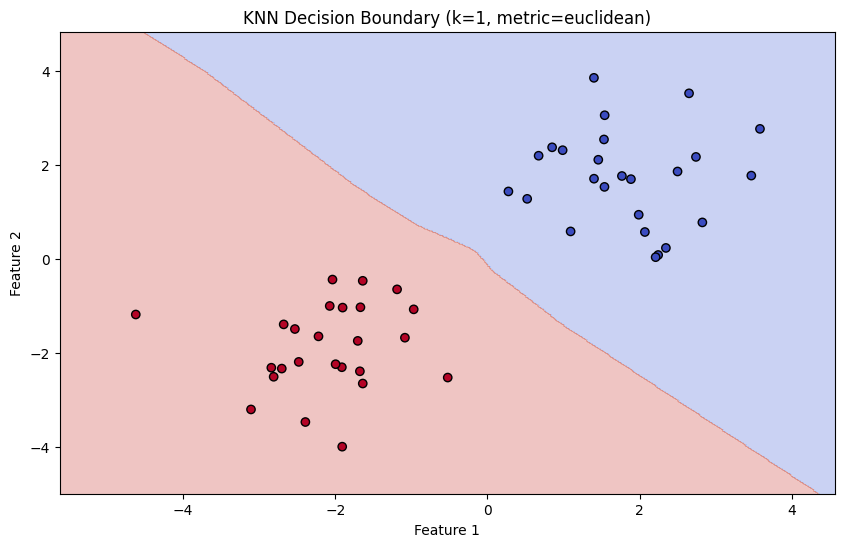

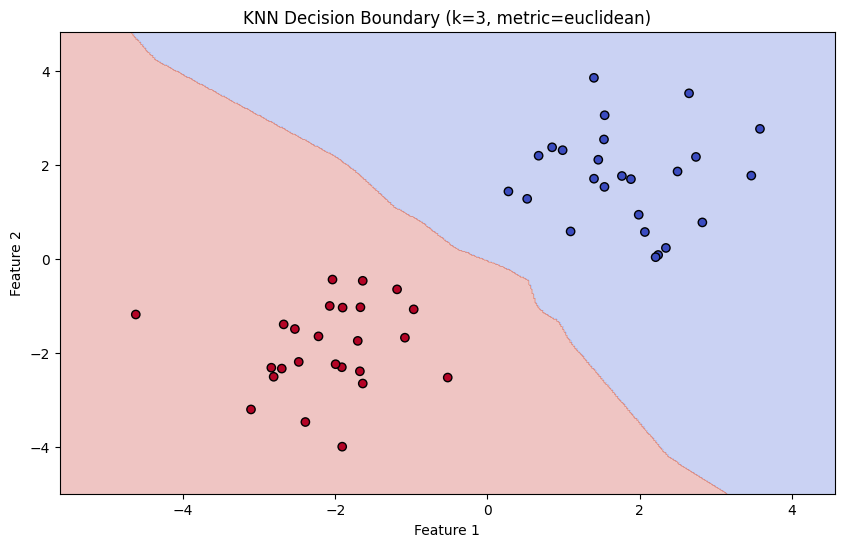

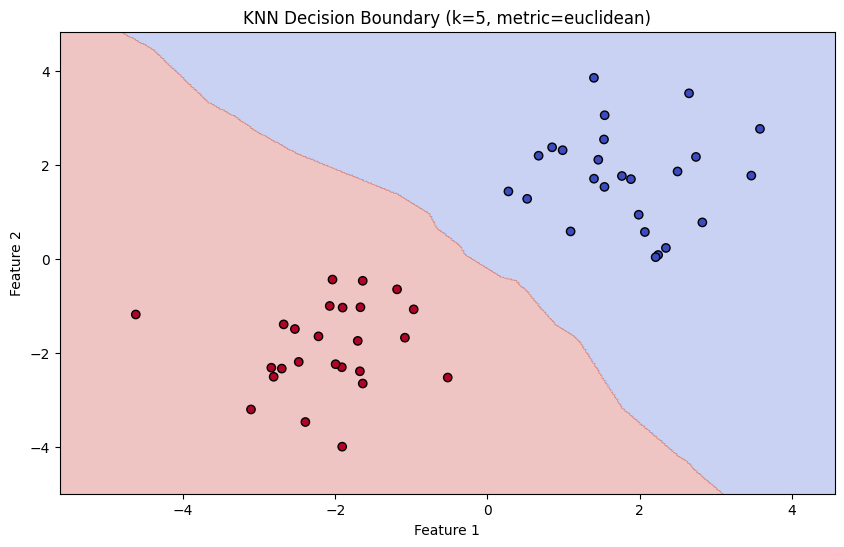

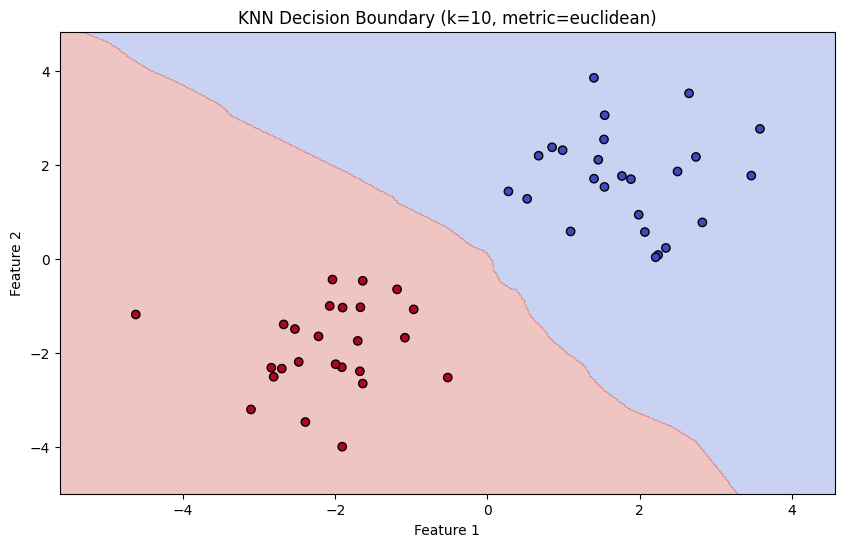

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

def generate_synth_data(n):
    # Generate some synthetic data for demonstration
    np.random.seed(42)
    X = np.concatenate(
        [np.random.randn(n // 2, 2) + np.array([2, 2]),
         np.random.randn(n // 2, 2) + np.array([-2, -2])]
    )
    y = np.concatenate([np.zeros(n // 2), np.ones(n // 2)])
    return X, y

def plot_decision_boundary(X, y, k_value, metric='euclidean'):

    h = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    knn = KNeighborsClassifier(
        n_neighbors=k_value,
        metric=metric
    )

    knn.fit(X, y)

    mesh_points = np.c_[xx.ravel(), yy.ravel()]

    Z = knn.predict(mesh_points)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor='k',
        cmap=plt.cm.coolwarm
    )

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'KNN Decision Boundary (k={k_value}, metric={metric})')

    plt.show()


n = 50
pts, tgts = generate_synth_data(n)

for k in [1, 3, 5, 10]:
    plot_decision_boundary(pts, tgts, k)

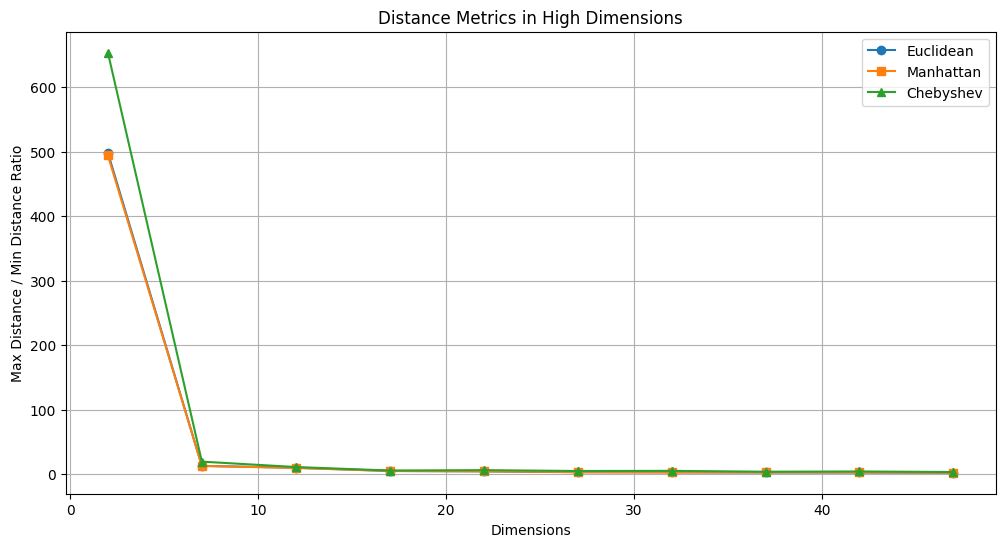

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

def analyze_distance_in_high_dims(max_dim=50, n_points=100):

    dimensions = range(2, max_dim + 1, 5)

    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    for dim in dimensions:

        points = np.random.randn(n_points, dim)

        euclidean_dist = pdist(points, metric='euclidean')
        euclidean_ratio = np.max(euclidean_dist) / np.min(euclidean_dist)

        manhattan_dist = pdist(points, metric='cityblock')
        manhattan_ratio = np.max(manhattan_dist) / np.min(manhattan_dist)

        chebyshev_dist = pdist(points, metric='chebyshev')
        chebyshev_ratio = np.max(chebyshev_dist) / np.min(chebyshev_dist)

        results['euclidean'].append(euclidean_ratio)
        results['manhattan'].append(manhattan_ratio)
        results['chebyshev'].append(chebyshev_ratio)

    plt.figure(figsize=(12, 6))

    plt.plot(dimensions, results['euclidean'], marker='o', label='Euclidean')
    plt.plot(dimensions, results['manhattan'], marker='s', label='Manhattan')
    plt.plot(dimensions, results['chebyshev'], marker='^', label='Chebyshev')

    plt.xlabel('Dimensions')
    plt.ylabel('Max Distance / Min Distance Ratio')

    plt.title('Distance Metrics in High Dimensions')

    plt.legend()
    plt.grid(True)

    plt.show()

    return results


results = analyze_distance_in_high_dims()